In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import logging

logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s | %(name)s | %(message)s")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

from src.config import cfg
from src.data.loader import load_features
from src.models.train import (
    compare_models,
    train_final_model,
    save_model,
    load_model,
    time_series_cv,
    compute_metrics,
    CANDIDATE_MODELS,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = load_features()
print(f"Feature matrix: {df.shape}")
print(f"Target: temp_c  |  range: {df['temp_c'].min():.1f} – {df['temp_c'].max():.1f}°C")

INFO | src.data.loader | Loading features from: C:\Users\CDAC\Documents\AI\weather\data\features\weather_features.parquet
INFO | src.data.loader | Loaded features: (8709, 39)


Feature matrix: (8709, 39)
Target: temp_c  |  range: -6.2 – 34.3°C


In [11]:
# This is the core evaluation. Takes ~2-3 minutes on a laptop.
print("Running model comparison (this trains each model across 5 CV folds)...\n")
comparison = compare_models(df)

INFO | src.models.train | Persistence baseline: MAE=0.488°C  RMSE=0.719  R²=0.9793
INFO | src.models.train | 
Training ridge...
INFO | src.models.train |   Fold 1/5 (train=1,454  test=1,451) MAE=0.602  R²=0.9773
INFO | src.models.train |   Fold 2/5 (train=2,905  test=1,451) MAE=0.472  R²=0.9847
INFO | src.models.train |   Fold 3/5 (train=4,356  test=1,451) MAE=0.493  R²=0.9817
INFO | src.models.train |   Fold 4/5 (train=5,807  test=1,451) MAE=0.445  R²=0.9877
INFO | src.models.train |   Fold 5/5 (train=7,258  test=1,451) MAE=0.353  R²=0.9873
INFO | src.models.train |   ridge: MAE=0.473  RMSE=0.655  R²=0.9837
INFO | src.models.train | 
Training random_forest...


Running model comparison (this trains each model across 5 CV folds)...



INFO | src.models.train |   Fold 1/5 (train=1,454  test=1,451) MAE=1.055  R²=0.9218
INFO | src.models.train |   Fold 2/5 (train=2,905  test=1,451) MAE=1.072  R²=0.9133
INFO | src.models.train |   Fold 3/5 (train=4,356  test=1,451) MAE=0.785  R²=0.9293
INFO | src.models.train |   Fold 4/5 (train=5,807  test=1,451) MAE=0.434  R²=0.9870
INFO | src.models.train |   Fold 5/5 (train=7,258  test=1,451) MAE=0.374  R²=0.9847
INFO | src.models.train |   random_forest: MAE=0.744  RMSE=1.131  R²=0.9472
INFO | src.models.train | 
Training gradient_boosting...
INFO | src.models.train |   Fold 1/5 (train=1,454  test=1,451) MAE=0.988  R²=0.9277
INFO | src.models.train |   Fold 2/5 (train=2,905  test=1,451) MAE=1.499  R²=0.8625
INFO | src.models.train |   Fold 3/5 (train=4,356  test=1,451) MAE=0.946  R²=0.8779
INFO | src.models.train |   Fold 4/5 (train=5,807  test=1,451) MAE=0.422  R²=0.9888
INFO | src.models.train |   Fold 5/5 (train=7,258  test=1,451) MAE=0.427  R²=0.9827
INFO | src.models.train |  

In [12]:
print("\n" + "=" * 58)
print("MODEL COMPARISON — sorted by MAE ascending")
print("=" * 58)
print(comparison.to_string(index=False))
print("=" * 58)
print(f"\nBest model: {comparison.iloc[0]['model']}  "
      f"(MAE={comparison.iloc[0]['mae']:.3f}°C)")

# ✅ Fixed: matches the name in compare_models()
baseline_row = comparison.loc[comparison["model"] == "persistence_baseline", "mae"]

if baseline_row.empty:
    # Safety net — prints available names so you can see what changed
    print(f"\nAvailable model names: {comparison['model'].tolist()}")
    print("Update the baseline name above to match.")
else:
    baseline_mae = baseline_row.values[0]
    best_mae     = comparison.iloc[0]["mae"]
    improvement  = (baseline_mae - best_mae) / baseline_mae * 100
    print(f"Persistence baseline MAE : {baseline_mae:.3f}°C")
    print(f"Best model MAE           : {best_mae:.3f}°C")
    print(f"Improvement over baseline: {improvement:.1f}%")


MODEL COMPARISON — sorted by MAE ascending
   mae   rmse    mape     r2                model
0.4731 0.6548 22.5355 0.9837                ridge
0.4880 0.7187 78.1575 0.9793 persistence_baseline
0.7439 1.1308 31.4263 0.9472        random_forest
0.8564 1.2836 36.4928 0.9279    gradient_boosting

Best model: ridge  (MAE=0.473°C)
Persistence baseline MAE : 0.488°C
Best model MAE           : 0.473°C
Improvement over baseline: 3.1%


C:\Users\CDAC\AppData\Local\Temp\ipykernel_14816\678096256.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["model"], rotation=20, ha="right", fontsize=9)
C:\Users\CDAC\AppData\Local\Temp\ipykernel_14816\678096256.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["model"], rotation=20, ha="right", fontsize=9)
C:\Users\CDAC\AppData\Local\Temp\ipykernel_14816\678096256.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["model"], rotation=20, ha="right", fontsize=9)


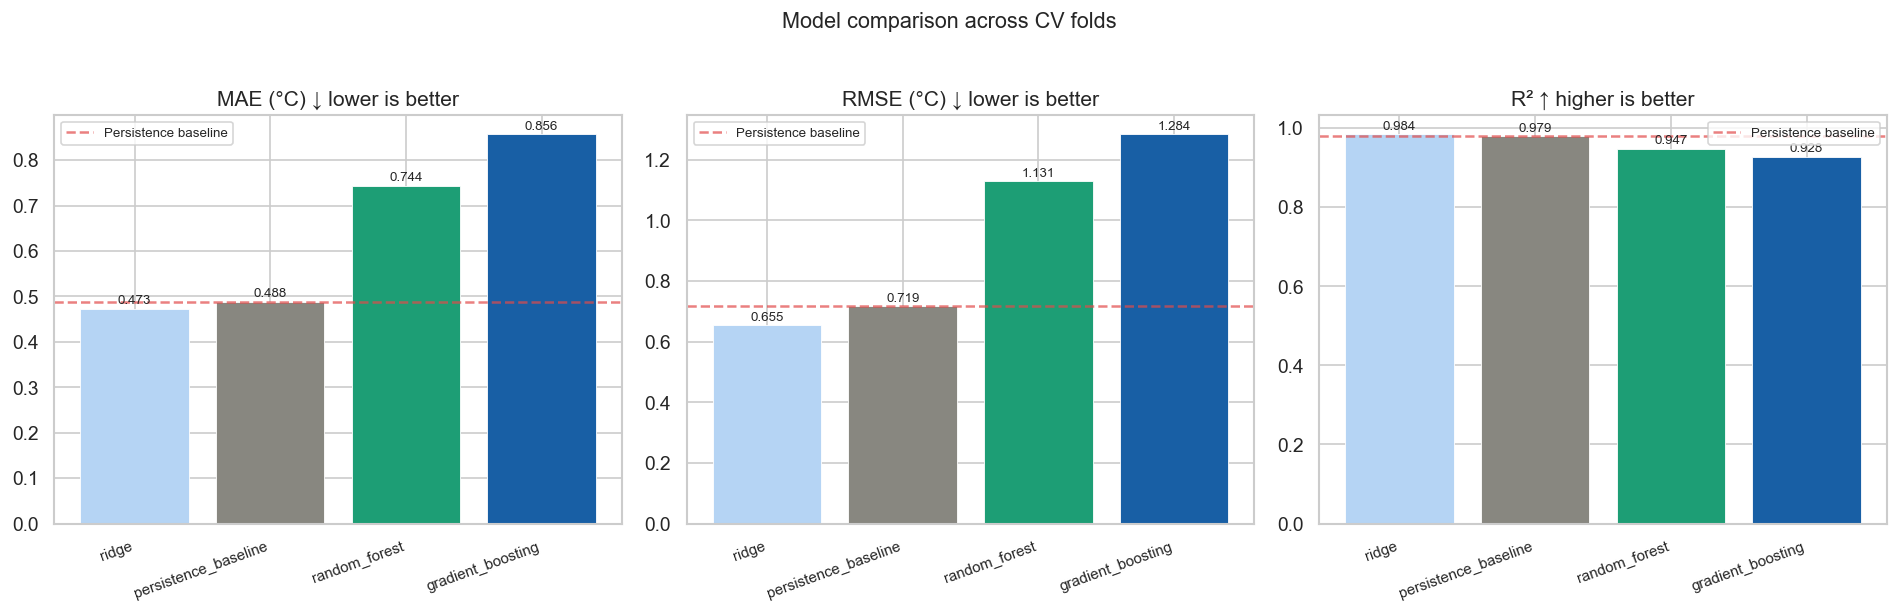

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["mae", "rmse", "r2"]
titles = ["MAE (°C) ↓ lower is better",
          "RMSE (°C) ↓ lower is better",
          "R² ↑ higher is better"]

# ✅ Updated key to match compare_models() output
colors = {
    "persistence_baseline": "#888780",
    "ridge":                "#B5D4F4",
    "random_forest":        "#1D9E75",
    "gradient_boosting":    "#185FA5",
}

# ✅ Updated name
BASELINE_NAME = "persistence_baseline"

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    bars = ax.bar(
        comparison["model"],
        comparison[metric],
        color=[colors.get(m, "#ccc") for m in comparison["model"]],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(title)
    ax.set_xticklabels(comparison["model"], rotation=20, ha="right", fontsize=9)

    # Label bar values
    for bar, val in zip(bars, comparison[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

    # ✅ Mark baseline with safe lookup
    baseline_row = comparison.loc[comparison["model"] == BASELINE_NAME, metric]
    if not baseline_row.empty:
        ax.axhline(
            baseline_row.values[0],
            color="#E24B4A", lw=1.5, ls="--", alpha=0.7,
            label="Persistence baseline"
        )
        ax.legend(fontsize=8)

plt.suptitle("Model comparison across CV folds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

INFO | src.models.train |   Fold 1/5 (train=1,454  test=1,451) MAE=0.602  R²=0.9773
INFO | src.models.train |   Fold 2/5 (train=2,905  test=1,451) MAE=0.472  R²=0.9847
INFO | src.models.train |   Fold 3/5 (train=4,356  test=1,451) MAE=0.493  R²=0.9817
INFO | src.models.train |   Fold 4/5 (train=5,807  test=1,451) MAE=0.445  R²=0.9877
INFO | src.models.train |   Fold 5/5 (train=7,258  test=1,451) MAE=0.353  R²=0.9873


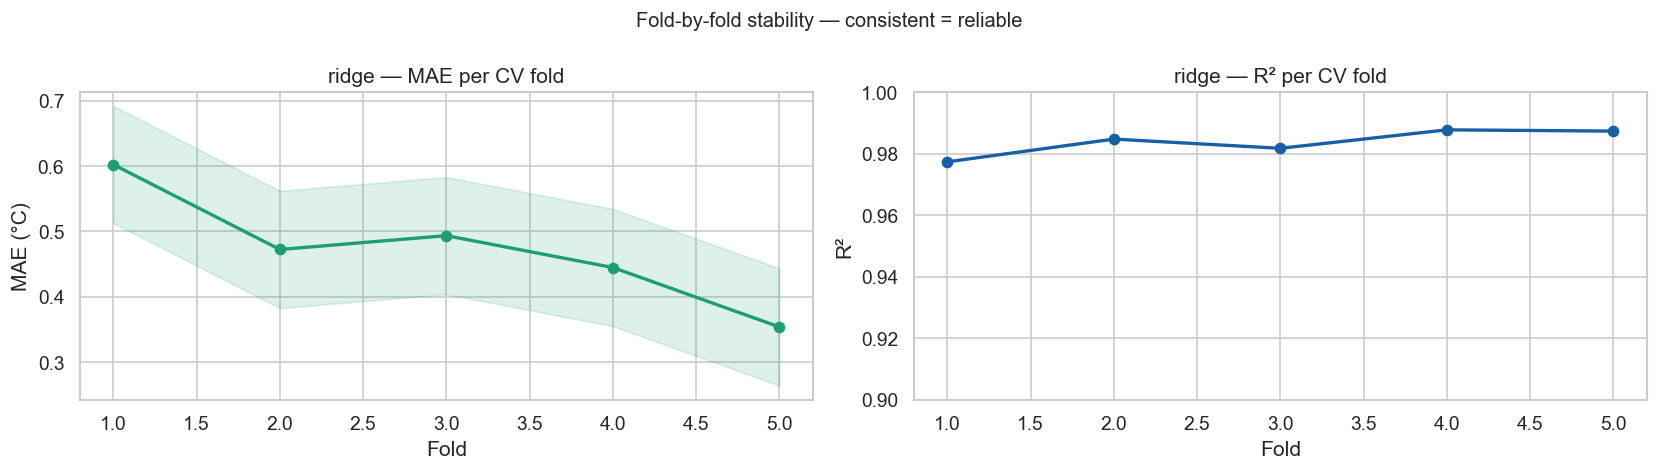

Fold-level results:
 fold  train_size  test_size    mae   rmse     r2
    1        1454       1451 0.6021 0.8593 0.9773
    2        2905       1451 0.4721 0.6782 0.9847
    3        4356       1451 0.4933 0.6697 0.9817
    4        5807       1451 0.4445 0.5763 0.9877
    5        7258       1451 0.3535 0.4903 0.9873


In [14]:
# Professional habit: check whether performance is consistent across folds.
# Degrading performance in later folds = distribution shift over time.

best_name = comparison.iloc[0]["model"]
pipe_check = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  CANDIDATE_MODELS[best_name]),
])

fold_results = time_series_cv(df, pipe_check, n_splits=5)
fold_df = pd.DataFrame(fold_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MAE per fold
axes[0].plot(fold_df["fold"], fold_df["mae"],
             marker="o", color="#1D9E75", lw=2)
axes[0].fill_between(fold_df["fold"],
                     fold_df["mae"] - fold_df["mae"].std(),
                     fold_df["mae"] + fold_df["mae"].std(),
                     alpha=0.15, color="#1D9E75")
axes[0].set_title(f"{best_name} — MAE per CV fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MAE (°C)")

# R² per fold
axes[1].plot(fold_df["fold"], fold_df["r2"],
             marker="o", color="#185FA5", lw=2)
axes[1].set_title(f"{best_name} — R² per CV fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0.9, 1.0)

plt.suptitle("Fold-by-fold stability — consistent = reliable", fontsize=12)
plt.tight_layout()
plt.show()

print("Fold-level results:")
print(fold_df[["fold", "train_size", "test_size", "mae", "rmse", "r2"]].to_string(index=False))

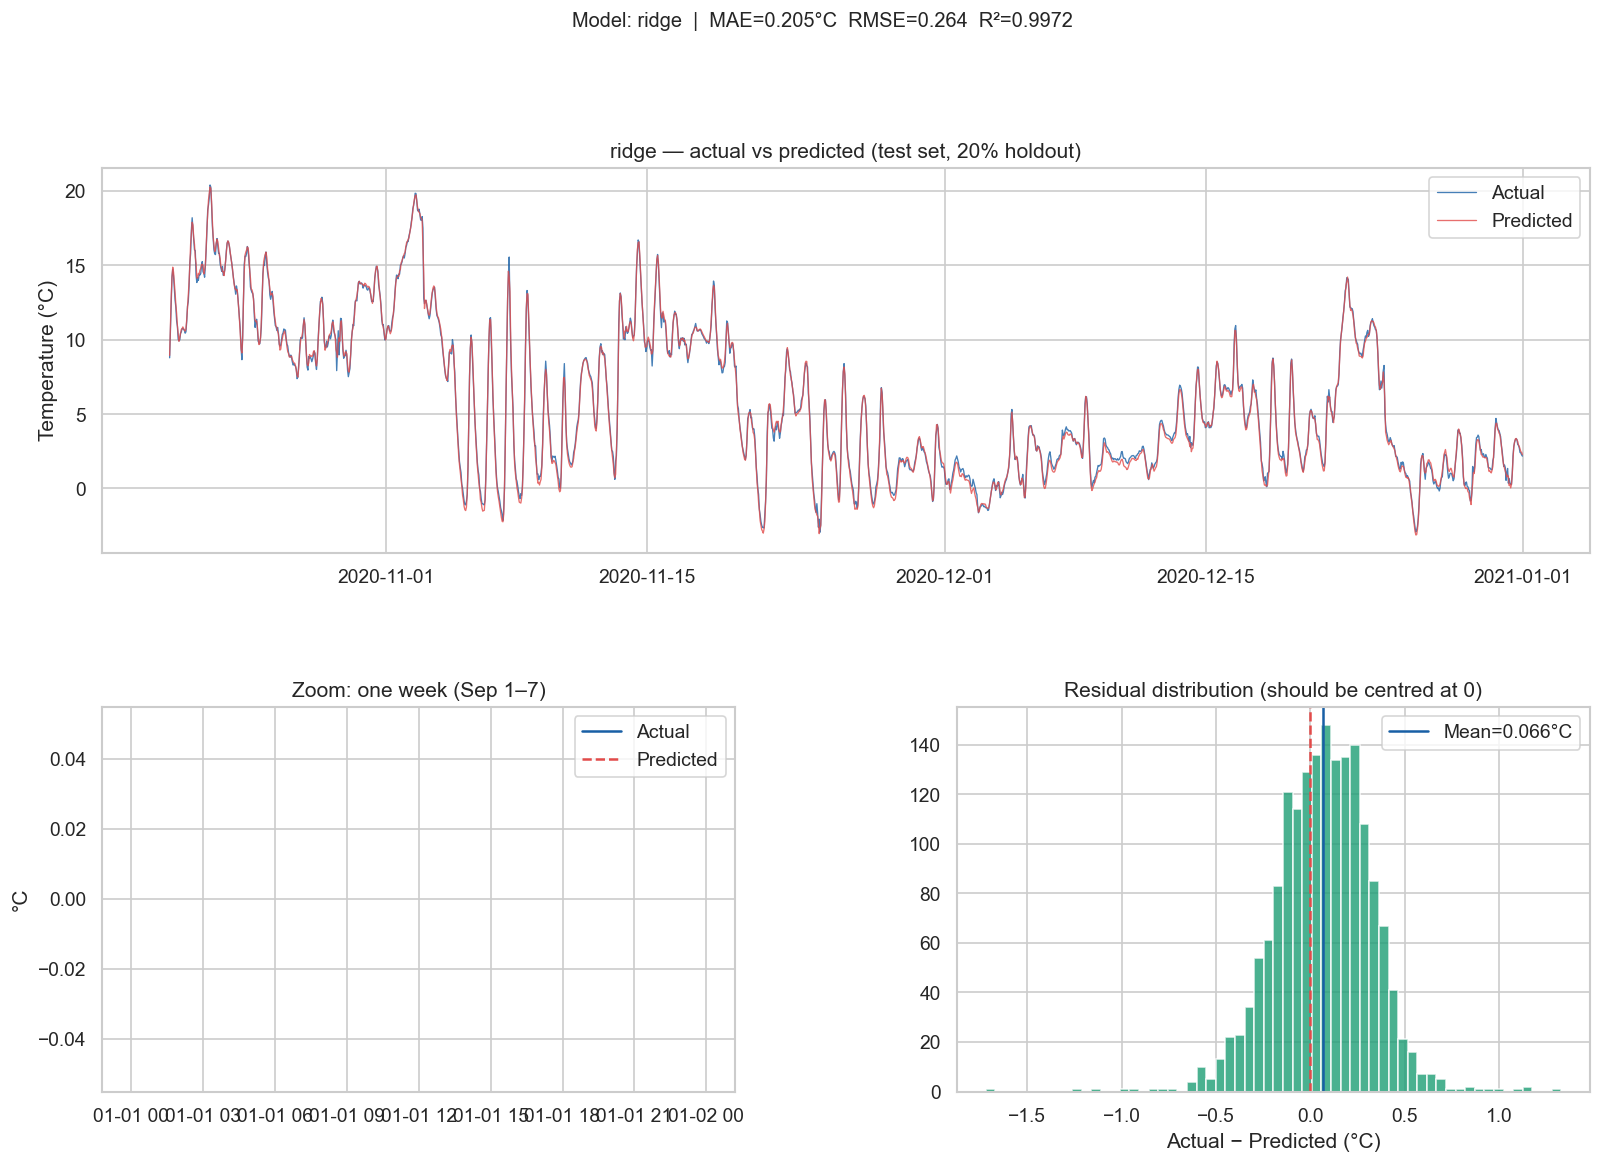

In [15]:
# Train on first 80%, predict on last 20% — a single honest split
feature_cols = [c for c in df.columns if c != "temp_c"]
X = df[feature_cols].values
y = df["temp_c"].values

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  CANDIDATE_MODELS[best_name]),
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

test_metrics = compute_metrics(y_test, y_pred)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Full test period
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, y_test, lw=0.8,
         color="#185FA5", alpha=0.8, label="Actual")
ax1.plot(dates_test, y_pred, lw=0.8,
         color="#E24B4A", alpha=0.8, label="Predicted")
ax1.set_title(f"{best_name} — actual vs predicted (test set, 20% holdout)")
ax1.set_ylabel("Temperature (°C)")
ax1.legend()

# Zoom in on one week
ax2 = fig.add_subplot(gs[1, 0])
week_mask = (dates_test >= "2020-09-01") & (dates_test < "2020-09-08")
ax2.plot(dates_test[week_mask], y_test[week_mask],
         lw=1.5, color="#185FA5", label="Actual")
ax2.plot(dates_test[week_mask], y_pred[week_mask],
         lw=1.5, color="#E24B4A", ls="--", label="Predicted")
ax2.set_title("Zoom: one week (Sep 1–7)")
ax2.set_ylabel("°C")
ax2.legend()

# Residuals
residuals = y_test - y_pred
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=60, color="#1D9E75", alpha=0.8, edgecolor="white")
ax3.axvline(0, color="#E24B4A", lw=1.5, ls="--")
ax3.axvline(residuals.mean(), color="#185FA5", lw=1.5,
            label=f"Mean={residuals.mean():.3f}°C")
ax3.set_title("Residual distribution (should be centred at 0)")
ax3.set_xlabel("Actual − Predicted (°C)")
ax3.legend()

plt.suptitle(
    f"Model: {best_name}  |  "
    f"MAE={test_metrics['mae']:.3f}°C  "
    f"RMSE={test_metrics['rmse']:.3f}  "
    f"R²={test_metrics['r2']:.4f}",
    fontsize=12, y=1.01
)
plt.show()

In [16]:
# Check: how much of Ridge's prediction is just the lag feature?
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [c for c in df.columns if c != "temp_c"]
X = df[feature_cols].values
y = df["temp_c"].values

split = int(len(df) * 0.8)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled[:split], y[:split])

# Find top coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": ridge.coef_,
    "abs_coef": np.abs(ridge.coef_)
}).sort_values("abs_coef", ascending=False)

print("Top 10 Ridge coefficients:")
print(coef_df.head(10).to_string(index=False))

Top 10 Ridge coefficients:
            feature  coefficient  abs_coef
      temp_c_lag_1h     3.815247  3.815247
     temp_c_next_1h     2.606651  2.606651
        dew_point_c     1.372371  1.372371
      temp_c_lag_2h    -1.185984  1.185984
       humidity_pct    -1.001291  1.001291
temp_c_roll_mean_3h     0.845256  0.845256
                par     0.146459  0.146459
          month_sin    -0.127793  0.127793
     temp_c_lag_12h    -0.108332  0.108332
      temp_c_lag_3h    -0.107234  0.107234


✅ Feature count : 38
✅ Target        : temp_c_next_1h
   temp_c_next_1h in features: False  ← must be False
   temp_c in features        : True  ← must be True

Explainer type : Linear
SHAP matrix    : (500, 38)  (rows × features)
Expected shape : (500, 38)


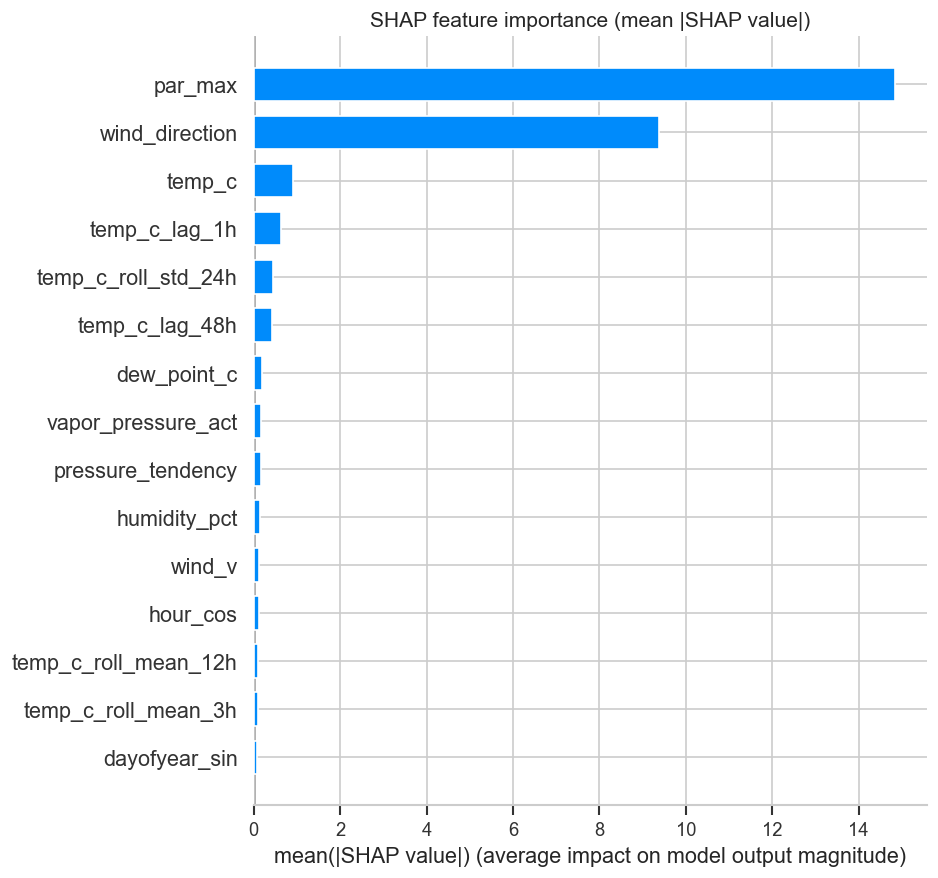

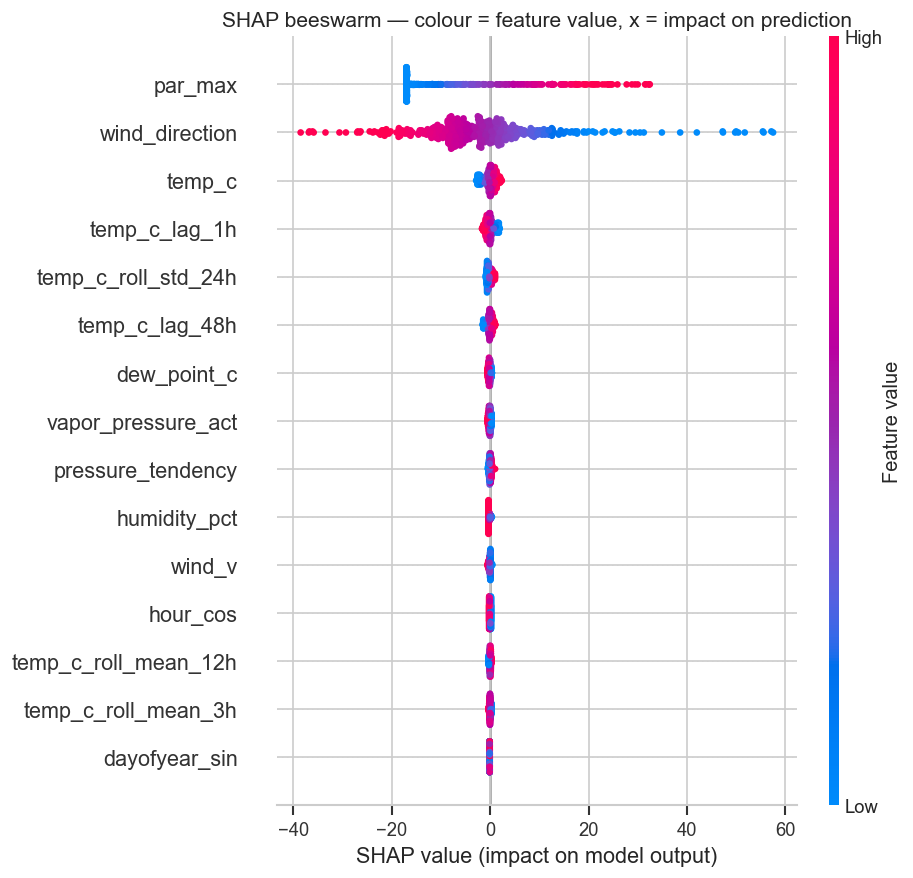


✅ temp_c_next_1h is absent from SHAP — no leakage
   Top feature: par_max (should be temp_c or temp_c_lag_1h)

Top 5 features by SHAP importance:
            feature  mean_shap
            par_max  14.835439
     wind_direction   9.390490
             temp_c   0.917331
      temp_c_lag_1h   0.631945
temp_c_roll_std_24h   0.450934


In [17]:
import shap

# ── Step 1: Redefine feature_cols correctly ───────────────────────────────
# Must exclude the TARGET (temp_c_next_1h), not the old column (temp_c).
# This is the line that was wrong in every prior cell — fix it here once.
TARGET_COL   = "temp_c_next_1h"
feature_cols = [c for c in df.columns if c != TARGET_COL]

# ── Step 2: Sanity check before SHAP runs ─────────────────────────────────
assert TARGET_COL not in feature_cols, \
    f"🚨 {TARGET_COL} is still in feature_cols — target leaked into SHAP"
assert "temp_c" in feature_cols, \
    "🚨 temp_c (current temp) is missing from features"

print(f"✅ Feature count : {len(feature_cols)}")
print(f"✅ Target        : {TARGET_COL}")
print(f"   temp_c_next_1h in features: {TARGET_COL in feature_cols}  ← must be False")
print(f"   temp_c in features        : {'temp_c' in feature_cols}  ← must be True")

# ── Step 3: Extract the fitted scaler and model from the pipeline ─────────
scaler = best_pipe.named_steps["scaler"]
model  = best_pipe.named_steps["model"]

# ── Step 4: Build SHAP sample using the correct feature set ───────────────
# iloc[split:split+500] takes 500 rows from the test period
shap_sample    = df[feature_cols].iloc[split:split + 500]
X_background   = scaler.transform(df[feature_cols].values)   # background for explainer
X_shap_scaled  = scaler.transform(shap_sample.values)

# ── Step 5: Choose explainer based on model type ──────────────────────────
# LinearExplainer for Ridge (exact, fast)
# TreeExplainer  for RandomForest / GradientBoosting (exact, fast)
model_type = type(model).__name__

if model_type == "Ridge":
    explainer = shap.LinearExplainer(model, X_background)
    shap_vals = explainer.shap_values(X_shap_scaled)
else:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap_scaled)

print(f"\nExplainer type : {'Linear' if model_type == 'Ridge' else 'Tree'}")
print(f"SHAP matrix    : {shap_vals.shape}  (rows × features)")
print(f"Expected shape : ({len(shap_sample)}, {len(feature_cols)})")

# ── Step 6: Bar plot — mean |SHAP| per feature ────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    shap_sample,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.gca().set_title("SHAP feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.savefig("../artifacts/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Step 7: Beeswarm — importance + direction ─────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    shap_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.gca().set_title("SHAP beeswarm — colour = feature value, x = impact on prediction")
plt.tight_layout()
plt.show()

# ── Step 8: Final check — target must be absent from top features ─────────
mean_abs_shap = pd.DataFrame({
    "feature":    feature_cols,
    "mean_shap":  np.abs(shap_vals).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

if TARGET_COL in mean_abs_shap["feature"].values:
    print(f"\n🚨 {TARGET_COL} appeared in SHAP — leakage still present")
else:
    print(f"\n✅ {TARGET_COL} is absent from SHAP — no leakage")
    print(f"   Top feature: {mean_abs_shap.iloc[0]['feature']} "
          f"(should be temp_c or temp_c_lag_1h)")

print("\nTop 5 features by SHAP importance:")
print(mean_abs_shap.head(5).to_string(index=False))

In [18]:
# Choose best model name from comparison
best_model_name = comparison.iloc[0]["model"]

print(f"Training final model: {best_model_name}")
print(f"Training on all {len(df):,} rows...\n")

final_pipeline, feature_cols_saved = train_final_model(
    df,
    model_name=best_model_name,
)

# Bundle CV metrics with the artifact
best_cv_metrics = {
    "mae":  comparison.iloc[0]["mae"],
    "rmse": comparison.iloc[0]["rmse"],
    "mape": comparison.iloc[0]["mape"],
    "r2":   comparison.iloc[0]["r2"],
}

save_model(final_pipeline, feature_cols_saved, cv_metrics=best_cv_metrics)

# Verify round-trip load
artifact = load_model()
print(f"\n✅ Artifact verified:")
print(f"   Model version : {artifact['model_version']}")
print(f"   Feature count : {len(artifact['feature_cols'])}")
print(f"   CV MAE        : {artifact['cv_metrics']['mae']:.3f}°C")
print(f"   CV R²         : {artifact['cv_metrics']['r2']:.4f}")
print(f"\nFirst 5 feature names:")
for name in artifact["feature_cols"][:5]:
    print(f"   {name}")

INFO | src.models.train | Training final ridge on 8,709 samples, 38 features, target='temp_c_next_1h'...


INFO | src.models.train | Final model training complete
INFO | src.models.train | Artifact saved → C:\Users\CDAC\Documents\AI\weather\artifacts\model.pkl
INFO | src.models.train |   version      : v1.0.0
INFO | src.models.train |   features     : 38
INFO | src.models.train |   target       : temp_c_next_1h
INFO | src.models.train | Model loaded: version=v1.0.0  features=38  target=temp_c_next_1h


Training final model: ridge
Training on all 8,709 rows...


✅ Artifact verified:
   Model version : v1.0.0
   Feature count : 38
   CV MAE        : 0.473°C
   CV R²         : 0.9837

First 5 feature names:
   pressure_mbar
   temp_c
   dew_point_c
   humidity_pct
   vapor_pressure_act


In [19]:
import shap

# ── Step 1: Get feature names EXACTLY as used during training ─────────────
TARGET_COL = "temp_c_next_1h"

# 🔥 Use training pipeline columns (NOT raw df)
feature_cols = best_pipe.feature_names_in_

# ── Step 2: Sanity checks ────────────────────────────────────────────────
assert TARGET_COL not in feature_cols, \
    f"🚨 {TARGET_COL} leaked into features"

assert "temp_c" in feature_cols, \
    "🚨 temp_c missing — something is wrong"

print(f"✅ Feature count : {len(feature_cols)}")
print(f"✅ Target        : {TARGET_COL}")
print(f"   temp_c_next_1h in features: {TARGET_COL in feature_cols}")
print(f"   temp_c in features        : {'temp_c' in feature_cols}")

# ── Step 3: Extract model + scaler ───────────────────────────────────────
scaler = best_pipe.named_steps["scaler"]
model  = best_pipe.named_steps["model"]

# ── Step 4: Build SHAP sample (aligned with training features) ───────────
shap_sample = df_features[feature_cols].iloc[split:split + 500]

# Background (use subset for speed)
X_background = scaler.transform(df_features[feature_cols].iloc[:1000])
X_shap_scaled = scaler.transform(shap_sample)

# ── Step 5: Choose correct explainer ─────────────────────────────────────
model_type = type(model).__name__

if model_type == "Ridge":
    explainer = shap.LinearExplainer(model, X_background)
    shap_vals = explainer.shap_values(X_shap_scaled)
else:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap_scaled)

print(f"\nExplainer type : {'Linear' if model_type == 'Ridge' else 'Tree'}")
print(f"SHAP matrix    : {shap_vals.shape}")

# ── Step 6: Bar plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    shap_sample,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("SHAP feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

# ── Step 7: Beeswarm ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    shap_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.title("SHAP beeswarm — feature impact")
plt.tight_layout()
plt.show()

# ── Step 8: Final leakage check ──────────────────────────────────────────
mean_abs_shap = pd.DataFrame({
    "feature": feature_cols,
    "mean_shap": np.abs(shap_vals).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

if TARGET_COL in mean_abs_shap["feature"].values:
    print(f"\n🚨 {TARGET_COL} appeared in SHAP — leakage present")
else:
    print(f"\n✅ No leakage detected")
    print(f"Top feature: {mean_abs_shap.iloc[0]['feature']}")

print("\nTop 5 features:")
print(mean_abs_shap.head(5).to_string(index=False))

AttributeError: 'StandardScaler' object has no attribute 'feature_names_in_'